<a href="https://colab.research.google.com/github/listenmusiceveryday/AIB6_Progress_Note/blob/main/google_vit_base_patch16_224.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Tongue Health Classification - Multi-label Baseline
## Fixed & Optimized Version

**Project:** Tongue Health Assessment (7 classes)

**Data Split:** 80% Train / 10% Val / 10% Test

**Model:** Vision Transformer + Classification Head (Medical-optimized)

---

## 1️⃣ Setup & Installation

In [ ]:
# Check GPU
!nvidia-smi

Sat May 23 12:26:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install packages
!pip install -q transformers==4.40.0 accelerate bitsandbytes
!pip install -q timm  # For vision models
!pip install -q datasets pillow opencv-python-headless
!pip install -q scikit-learn pandas matplotlib seaborn
!pip install -q tensorboard  # For monitoring
!pip install -q torchmetrics  # Better metrics

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm.auto import tqdm
import warnings
import time
warnings.filterwarnings('ignore')

from transformers import (
    AutoImageProcessor,
    AutoModel,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    accuracy_score
)

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4
GPU Memory: 14.56 GB


## 2️⃣ Mount Google Drive & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ========================================
# Configuration - แก้ตรงนี้ให้ตรงกับโครงสร้างของคุณ
# ========================================

PROJECT_ROOT = Path('/content/drive/MyDrive/kaggle_dataset')  # ⬅️ แก้ตรงนี้
DATA_DIR = PROJECT_ROOT / 'shezhenv3-txt'
IMAGE_DIR = DATA_DIR / 'images'
LABELS_FILE = DATA_DIR / 'merge_train_val_test.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODEL_SAVE_DIR = OUTPUT_DIR / 'best_model'

# Create directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 7 Classes - แก้ตามคลาสจริงของคุณ
LABEL_COLUMNS = [
    'Color_Pink',      # ลิ้นซีด
    'Color_Red',       # ลิ้นแดง
    'Coating_White',    # ตะไคร่ลิ้นหนา
    'Coating_Yellow',     # ตะไคร่ลิ้นบาง
    'Geographic_Tongue',           # รอยแตก
    'Texture_Cracked',       # ลิ้นแห้ง
    'Texture_Dentate',          # บวม
]

NUM_LABELS = len(LABEL_COLUMNS)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Project: {PROJECT_ROOT}")
print(f"✓ Data: {IMAGE_DIR}")
print(f"✓ Labels file: {LABELS_FILE}")
print(f"✓ Number of classes: {NUM_LABELS}")
print(f"✓ Device: {DEVICE}")
print(f"\nClasses:")
for i, label in enumerate(LABEL_COLUMNS, 1):
    print(f"  {i}. {label}")

✓ Project: /content/drive/MyDrive/kaggle_dataset
✓ Data: /content/drive/MyDrive/kaggle_dataset/shezhenv3-txt/images
✓ Labels file: /content/drive/MyDrive/kaggle_dataset/shezhenv3-txt/merge_train_val_test.csv
✓ Number of classes: 7
✓ Device: cuda

Classes:
  1. Color_Pink
  2. Color_Red
  3. Coating_White
  4. Coating_Yellow
  5. Geographic_Tongue
  6. Texture_Cracked
  7. Texture_Dentate


## 3️⃣ Load & Explore Dataset

In [ ]:
# Load CSV
df = pd.read_csv(LABELS_FILE)

print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

Total samples: 3220

Columns: ['Image_Name', 'Color_Pink', 'Color_Red', 'Coating_White', 'Coating_Yellow', 'Geographic_Tongue', 'Texture_Cracked', 'Texture_Dentate']

First few rows:


,Image_Name,Color_Pink,Color_Red,Coating_White,Coating_Yellow,Geographic_Tongue,Texture_Cracked,Texture_Dentate
0,10255.jpg,0,1,1,0,0,0,0
1,A (219).jpg,0,1,1,0,0,0,0
2,10028.jpg,0,0,1,0,0,0,0
3,10607.jpg,0,1,1,0,0,0,0
4,A (227).jpg,0,0,1,0,0,1,0



Missing values:
Image_Name           0
Color_Pink           0
Color_Red            0
Coating_White        0
Coating_Yellow       0
Geographic_Tongue    0
Texture_Cracked      0
Texture_Dentate      0
dtype: int64


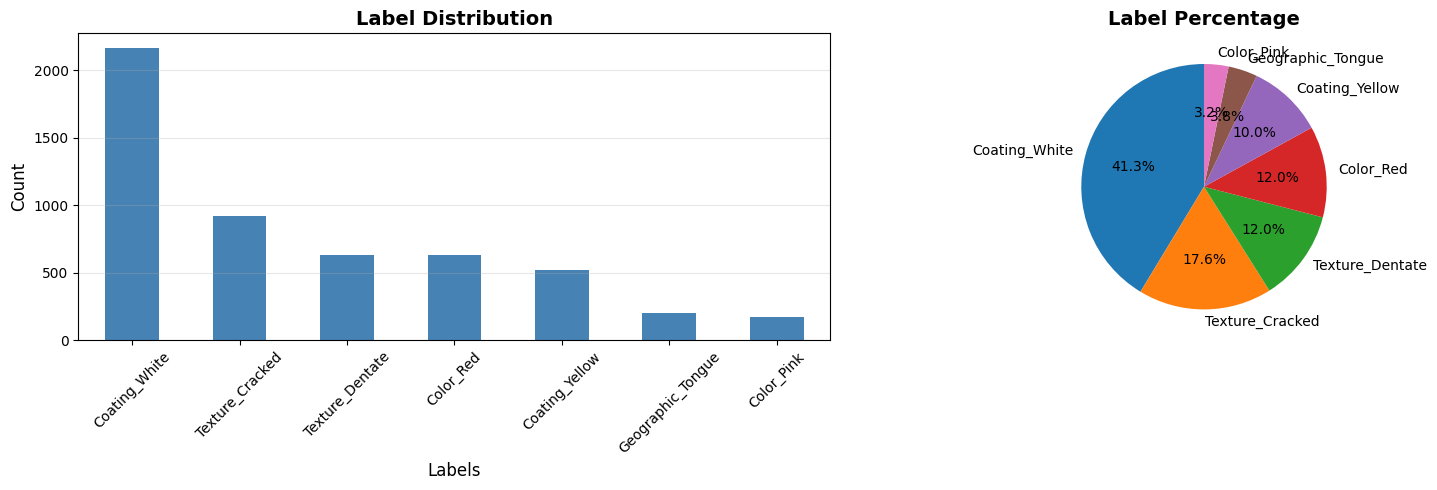


Label statistics:
  Coating_White       : 2167 ( 67.3%)
  Texture_Cracked     :  923 ( 28.7%)
  Texture_Dentate     :  631 ( 19.6%)
  Color_Red           :  629 ( 19.5%)
  Coating_Yellow      :  522 ( 16.2%)
  Geographic_Tongue   :  201 (  6.2%)
  Color_Pink          :  169 (  5.2%)


In [ ]:
# Label distribution
label_counts = df[LABEL_COLUMNS].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
label_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Label Distribution', fontsize=14, weight='bold')
ax1.set_xlabel('Labels', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Label Percentage', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLabel statistics:")
for label, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {label:20s}: {count:4d} ({percentage:5.1f}%)")

Multi-label statistics:
  Min labels per image: 0
  Max labels per image: 4
  Avg labels per image: 1.63
  Median labels per image: 2


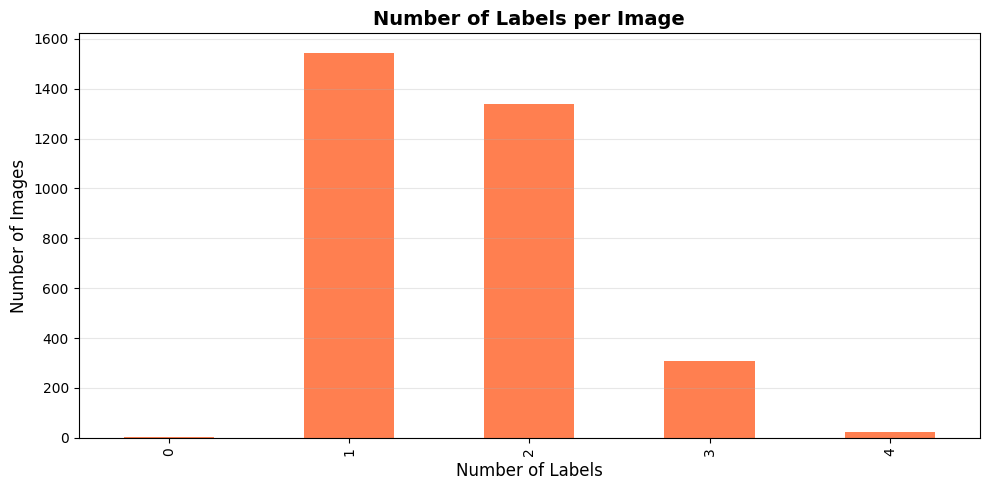

In [ ]:
# Multi-label statistics
labels_per_image = df[LABEL_COLUMNS].sum(axis=1)

print("Multi-label statistics:")
print(f"  Min labels per image: {labels_per_image.min()}")
print(f"  Max labels per image: {labels_per_image.max()}")
print(f"  Avg labels per image: {labels_per_image.mean():.2f}")
print(f"  Median labels per image: {labels_per_image.median():.0f}")

plt.figure(figsize=(10, 5))
labels_per_image.value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Number of Labels per Image', fontsize=14, weight='bold')
plt.xlabel('Number of Labels', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'labels_per_image.png', dpi=300, bbox_inches='tight')
plt.show()

## 4️⃣ Data Split: 80% Train / 10% Val / 10% Test

In [ ]:
# 80/10/10 split
# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# Second split: 10% val, 10% test from temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of 20% = 10%
    random_state=42,
    shuffle=True
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "="*50)
print("DATA SPLIT (80/10/10)")
print("="*50)
print(f"Train: {len(train_df):4d} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df):4d} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df):4d} samples ({len(test_df)/len(df)*100:.1f}%)")
print(f"Total: {len(df):4d} samples")
print("="*50)


DATA SPLIT (80/10/10)
Train: 2576 samples (80.0%)
Val:    322 samples (10.0%)
Test:   322 samples (10.0%)
Total: 3220 samples


## 5️⃣ Load Vision Model (Medical-optimized)

In [ ]:
# Use Vision Transformer (ViT) - good for medical images
MODEL_NAME = "google/vit-base-patch16-224"
# Alternative: "microsoft/swin-base-patch4-window7-224" (better but slower)

print(f"Loading vision model: {MODEL_NAME}...")

image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
vision_encoder = AutoModel.from_pretrained(MODEL_NAME)

print(f"✓ Vision encoder loaded")
print(f"  Hidden size: {vision_encoder.config.hidden_size}")
print(f"  Image size: {vision_encoder.config.image_size}")

Loading vision model: google/vit-base-patch16-224...


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Vision encoder loaded
  Hidden size: 768
  Image size: 224


## 6️⃣ Create Dataset Class

In [ ]:
class TongueHealthDataset(Dataset):
    """
    Multi-label tongue health dataset
    """
    def __init__(self, df, image_dir, label_columns, image_processor, augment=False):
        self.df = df
        self.image_dir = Path(image_dir)
        self.label_columns = label_columns
        self.image_processor = image_processor
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img_path = self.image_dir / row['Image_Name']
        image = Image.open(img_path).convert('RGB')

        # Simple augmentation (only for training)
        if self.augment:
            # Random horizontal flip
            if np.random.random() > 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)

            # Random rotation (-10 to 10 degrees)
            angle = np.random.uniform(-10, 10)
            image = image.rotate(angle, fillcolor=(255, 255, 255))

        # Get labels (multi-label binary vector)
        labels = torch.tensor(
            [row[label] for label in self.label_columns],
            dtype=torch.float32
        )

        # Process image
        inputs = self.image_processor(
            images=image,
            return_tensors="pt"
        )

        pixel_values = inputs['pixel_values'].squeeze(0)

        return {
            'pixel_values': pixel_values,
            'labels': labels
        }

# Create datasets
train_dataset = TongueHealthDataset(
    train_df, IMAGE_DIR, LABEL_COLUMNS, image_processor, augment=True
)
val_dataset = TongueHealthDataset(
    val_df, IMAGE_DIR, LABEL_COLUMNS, image_processor, augment=False
)
test_dataset = TongueHealthDataset(
    test_df, IMAGE_DIR, LABEL_COLUMNS, image_processor, augment=False
)

print(f"\n✓ Datasets created:")
print(f"  Train: {len(train_dataset)} (with augmentation)")
print(f"  Val:   {len(val_dataset)}")
print(f"  Test:  {len(test_dataset)}")

# Test loading
sample = train_dataset[0]
print(f"\nSample:")
print(f"  Image shape: {sample['pixel_values'].shape}")
print(f"  Labels shape: {sample['labels'].shape}")
print(f"  Labels: {sample['labels'].numpy()}")


✓ Datasets created:
  Train: 2576 (with augmentation)
  Val:   322
  Test:  322

Sample:
  Image shape: torch.Size([3, 224, 224])
  Labels shape: torch.Size([7])
  Labels: [0. 0. 0. 1. 0. 0. 0.]


## 7️⃣ Create Classification Model

In [ ]:
class TongueHealthClassifier(nn.Module):
    """
    Vision Transformer + Multi-label Classification Head
    Optimized for medical imaging
    """
    def __init__(self, vision_encoder, num_labels, dropout=0.3, freeze_backbone=False):
        super().__init__()

        self.vision_encoder = vision_encoder
        self.num_labels = num_labels
        hidden_size = vision_encoder.config.hidden_size

        # Optionally freeze backbone for faster training
        if freeze_backbone:
            for param in self.vision_encoder.parameters():
                param.requires_grad = False
            print("  ⚠️ Vision encoder frozen")

        # Classification head (3-layer MLP with residual connections)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout * 0.7),

            nn.Linear(256, num_labels)
        )

        # Initialize classifier weights
        self._init_weights()

    def _init_weights(self):
        """Initialize classifier weights"""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, pixel_values, labels=None):
        # Extract features
        outputs = self.vision_encoder(pixel_values=pixel_values)

        # Get pooled output (CLS token for ViT)
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0, :]  # CLS token

        # Classify
        logits = self.classifier(pooled)

        # Compute loss if labels provided
        loss = None
        if labels is not None:
            # Use BCEWithLogitsLoss (includes sigmoid)
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels)

        return {
            'loss': loss,
            'logits': logits,
        }

# Create model
model = TongueHealthClassifier(
    vision_encoder=vision_encoder,
    num_labels=NUM_LABELS,
    dropout=0.3,
    freeze_backbone=False  # Set True for faster training
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model created:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024**2:.1f} MB")


✓ Model created:
  Total parameters: 86,917,639
  Trainable parameters: 86,917,639
  Model size: ~331.6 MB


## 8️⃣ Training Configuration (Optimized)

In [ ]:
# ========================================
# Training Hyperparameters (Optimized)
# ========================================

BATCH_SIZE = 16  # Adjust based on GPU memory
NUM_EPOCHS = 30
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 0.01
WARMUP_EPOCHS = 3
PATIENCE = 7  # Early stopping patience

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Optimizer (AdamW with weight decay)
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Learning rate scheduler (Cosine with warm restarts)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=len(train_loader) * 5,  # Restart every 5 epochs
    T_mult=2,
    eta_min=1e-6
)

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Warmup epochs: {WARMUP_EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"\nSteps per epoch: {len(train_loader)}")
print(f"Total training steps: {total_steps}")
print("="*50)


TRAINING CONFIGURATION
Batch size: 16
Epochs: 30
Learning rate: 0.0002
Weight decay: 0.01
Warmup epochs: 3
Early stopping patience: 7

Steps per epoch: 161
Total training steps: 4830


## 9️⃣ Training Functions

In [ ]:
def compute_metrics(preds, labels, threshold=0.5):
    """
    Compute multi-label classification metrics
    """
    # Convert to numpy
    if isinstance(preds, torch.Tensor):
        preds = preds.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()

    # Apply sigmoid and threshold
    probs = 1 / (1 + np.exp(-preds))  # Sigmoid
    y_pred = (probs > threshold).astype(int)
    y_true = labels.astype(int)

    # Compute metrics
    metrics = {
        'exact_match': (y_pred == y_true).all(axis=1).mean(),
        'hamming_loss': hamming_loss(y_true, y_pred),
        'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
    }

    return metrics


def train_one_epoch(model, train_loader, optimizer, scheduler, device, epoch):
    """
    Train for one epoch
    """
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for batch in pbar:
        # Move to device
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs['loss']

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        # Track metrics
        total_loss += loss.item()
        all_preds.append(outputs['logits'].detach())
        all_labels.append(labels.detach())

        # Update progress bar
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'lr': f"{scheduler.get_last_lr()[0]:.2e}"
        })

    # Compute epoch metrics
    avg_loss = total_loss / len(train_loader)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    metrics = compute_metrics(all_preds, all_labels)
    metrics['loss'] = avg_loss

    return metrics


@torch.no_grad()
def evaluate(model, data_loader, device):
    """
    Evaluate model
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc="Evaluating"):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)

        total_loss += outputs['loss'].item()
        all_preds.append(outputs['logits'])
        all_labels.append(labels)

    # Compute metrics
    avg_loss = total_loss / len(data_loader)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    metrics = compute_metrics(all_preds, all_labels)
    metrics['loss'] = avg_loss

    return metrics, all_preds, all_labels


print("✓ Training functions defined")

✓ Training functions defined


## 🔟 Start Training!

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_f1': [],
    'val_loss': [],
    'val_f1': [],
    'lr': []
}

best_val_f1 = 0
patience_counter = 0
start_time = time.time()

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # Train
    train_metrics = train_one_epoch(
        model, train_loader, optimizer, scheduler, DEVICE, epoch
    )

    # Validate
    val_metrics, _, _ = evaluate(model, val_loader, DEVICE)

    # Log metrics
    history['train_loss'].append(train_metrics['loss'])
    history['train_f1'].append(train_metrics['f1_macro'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['f1_macro'])
    history['lr'].append(scheduler.get_last_lr()[0])

    epoch_time = time.time() - epoch_start

    # Print results
    print(f"\nEpoch {epoch}/{NUM_EPOCHS} ({epoch_time:.1f}s)")
    print(f"  Train - Loss: {train_metrics['loss']:.4f}, F1: {train_metrics['f1_macro']:.4f}")
    print(f"  Val   - Loss: {val_metrics['loss']:.4f}, F1: {val_metrics['f1_macro']:.4f}")

    # Save best model
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        patience_counter = 0

        # Save model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'train_metrics': train_metrics,
            'val_metrics': val_metrics,
        }, MODEL_SAVE_DIR / 'best_model.pt')

        print(f"  ✓ New best model saved! (F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping triggered after {epoch} epochs")
        break

total_time = time.time() - start_time
print(f"\n" + "="*70)
print(f"TRAINING COMPLETED in {total_time/60:.1f} minutes")
print(f"Best Validation F1: {best_val_f1:.4f}")
print("="*70)


STARTING TRAINING


Epoch 1:   0%|          | 0/161 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


Epoch 1/30 (105.0s)
  Train - Loss: 0.4058, F1: 0.3804
  Val   - Loss: 0.3579, F1: 0.4732
  ✓ New best model saved! (F1: 0.4732)


Epoch 2:   0%|          | 0/161 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


Epoch 11/30 (101.7s)
  Train - Loss: 0.0799, F1: 0.9404
  Val   - Loss: 0.3181, F1: 0.7391
  No improvement (6/7)


Epoch 12:   0%|          | 0/161 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


Epoch 12/30 (103.1s)
  Train - Loss: 0.0550, F1: 0.9609
  Val   - Loss: 0.3401, F1: 0.7459
  No improvement (7/7)

⚠️ Early stopping triggered after 12 epochs

TRAINING COMPLETED in 23.2 minutes
Best Validation F1: 0.7550


## 1️⃣1️⃣ Plot Training History

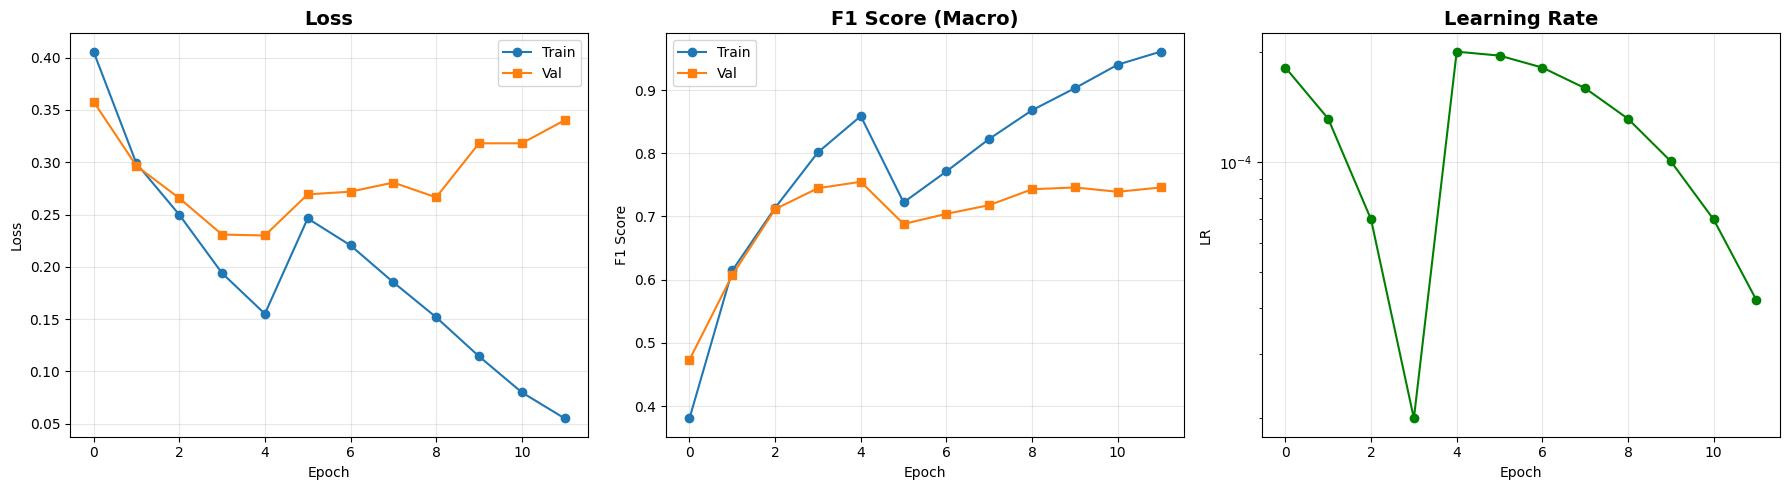

✓ Training history saved


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_title('Loss', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 Score
axes[1].plot(history['train_f1'], label='Train', marker='o')
axes[1].plot(history['val_f1'], label='Val', marker='s')
axes[1].set_title('F1 Score (Macro)', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(history['lr'], color='green', marker='o')
axes[2].set_title('Learning Rate', fontsize=14, weight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Save history
with open(OUTPUT_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("✓ Training history saved")

## 1️⃣2️⃣ Load Best Model & Evaluate on Test Set

In [ ]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_DIR / 'best_model.pt', weights_only=False)

# 2. บรรทัดอื่น ๆ ปล่อยไว้เหมือนเดิม
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Best model loaded (Epoch {checkpoint['epoch']})")

print(f"✓ Best model loaded (Epoch {checkpoint['epoch']})")
print(f"  Validation F1: {checkpoint['best_val_f1']:.4f}")

# Evaluate on test set
print("\nEvaluating on test set...")
test_metrics, test_preds, test_labels = evaluate(model, test_loader, DEVICE)

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Exact Match Accuracy: {test_metrics['exact_match']:.4f}")
print(f"Hamming Loss: {test_metrics['hamming_loss']:.4f}")
print(f"\nF1 Scores:")
print(f"  Micro:    {test_metrics['f1_micro']:.4f}")
print(f"  Macro:    {test_metrics['f1_macro']:.4f}")
print(f"  Weighted: {test_metrics['f1_weighted']:.4f}")
print(f"\nPrecision (Micro): {test_metrics['precision_micro']:.4f}")
print(f"Recall (Micro):    {test_metrics['recall_micro']:.4f}")
print("="*70)

# Save test metrics
with open(OUTPUT_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"\n✓ Test metrics saved to {OUTPUT_DIR / 'test_metrics.json'}")

✓ Best model loaded (Epoch 5)
✓ Best model loaded (Epoch 5)
  Validation F1: 0.7550

Evaluating on test set...


Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


TEST SET RESULTS
Loss: 0.1876
Exact Match Accuracy: 0.6118
Hamming Loss: 0.0816

F1 Scores:
  Micro:    0.8185
  Macro:    0.7917
  Weighted: 0.8133

Precision (Micro): 0.8218
Recall (Micro):    0.8153

✓ Test metrics saved to /content/drive/MyDrive/kaggle_dataset/outputs/test_metrics.json


## 1️⃣3️⃣ Per-Class Performance


PER-CLASS PERFORMANCE
Class                      F1    Precision     Recall    Support
----------------------------------------------------------------------
Color_Pink             0.8000       0.9231     0.7059         17
Color_Red              0.5932       0.5833     0.6034         58
Coating_White          0.9150       0.8787     0.9545        220
Coating_Yellow         0.7848       0.8378     0.7381         42
Geographic_Tongue      1.0000       1.0000     1.0000         22
Texture_Cracked        0.7886       0.7500     0.8313         83
Texture_Dentate        0.6606       0.8571     0.5373         67


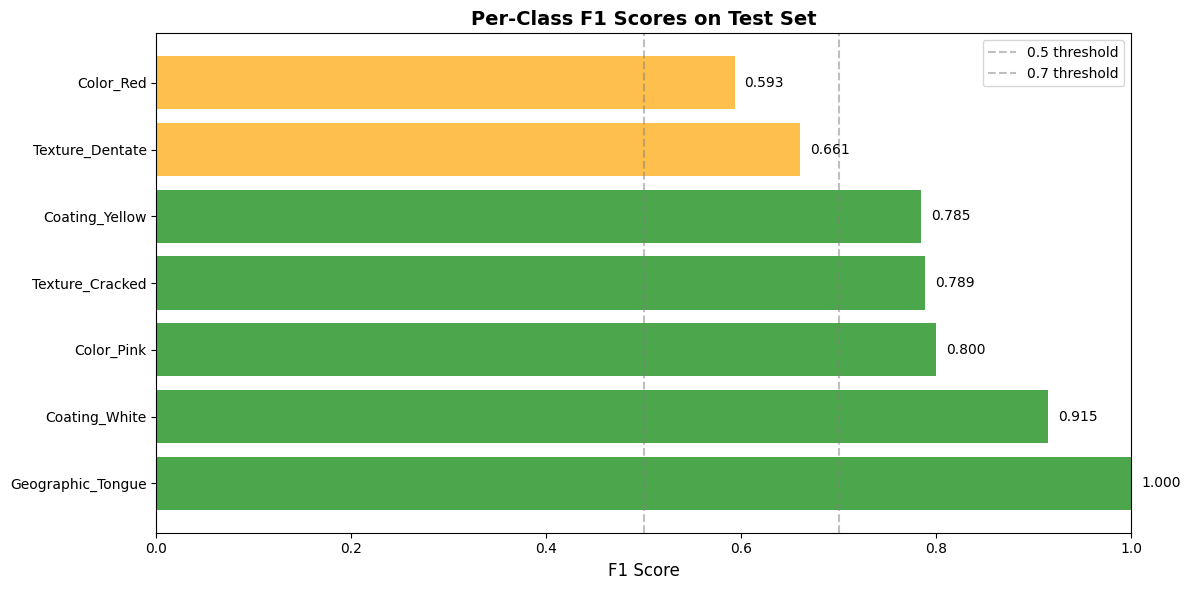

In [ ]:
# Per-class metrics
test_preds_np = test_preds.cpu().numpy()
test_labels_np = test_labels.cpu().numpy()

# Apply sigmoid and threshold
probs = 1 / (1 + np.exp(-test_preds_np))
y_pred = (probs > 0.5).astype(int)
y_true = test_labels_np.astype(int)

# Compute per-class F1
per_class_f1 = {}
per_class_precision = {}
per_class_recall = {}

for i, label in enumerate(LABEL_COLUMNS):
    per_class_f1[label] = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    per_class_precision[label] = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    per_class_recall[label] = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)

# Print per-class results
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE")
print("="*70)
print(f"{'Class':<20} {'F1':>8} {'Precision':>12} {'Recall':>10} {'Support':>10}")
print("-" * 70)
for i, label in enumerate(LABEL_COLUMNS):
    support = y_true[:, i].sum()
    print(f"{label:<20} {per_class_f1[label]:>8.4f} {per_class_precision[label]:>12.4f} "
          f"{per_class_recall[label]:>10.4f} {support:>10.0f}")
print("="*70)

# Visualize per-class F1
plt.figure(figsize=(12, 6))
sorted_labels = sorted(per_class_f1.items(), key=lambda x: x[1], reverse=True)
labels, scores = zip(*sorted_labels)

colors = ['green' if s > 0.7 else 'orange' if s > 0.5 else 'red' for s in scores]
plt.barh(labels, scores, color=colors, alpha=0.7)
plt.xlabel('F1 Score', fontsize=12)
plt.title('Per-Class F1 Scores on Test Set', fontsize=14, weight='bold')
plt.xlim(0, 1)

for i, v in enumerate(scores):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='0.7 threshold')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

## 1️⃣4️⃣ Confusion Matrices

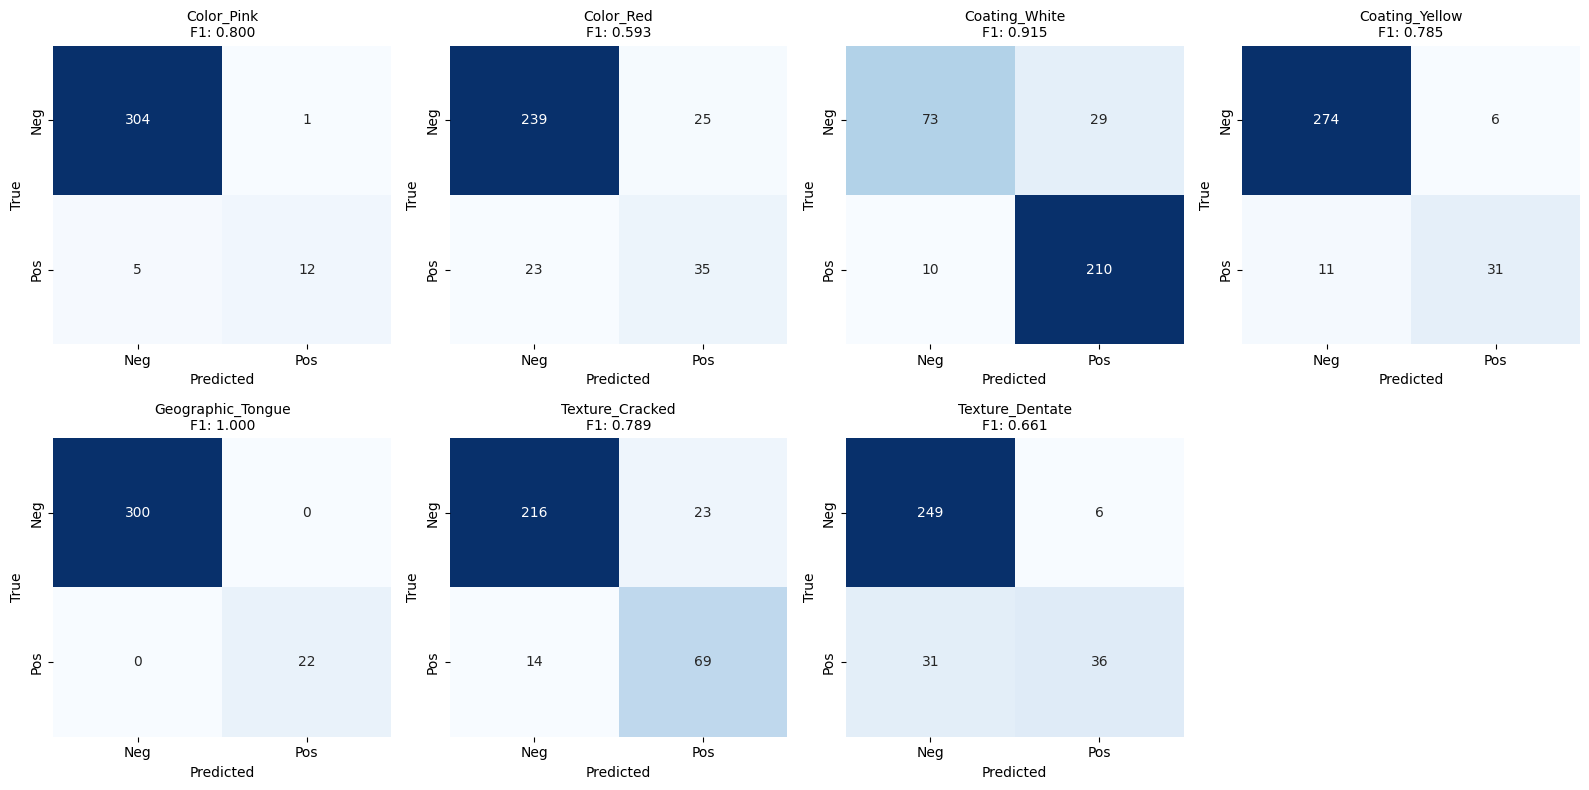

In [ ]:
# Confusion matrix per label
cm_multi = multilabel_confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (label, cm) in enumerate(zip(LABEL_COLUMNS, cm_multi)):
    if i < len(axes):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                    cbar=False)
        axes[i].set_title(f'{label}\nF1: {per_class_f1[label]:.3f}', fontsize=10)
        axes[i].set_ylabel('True')
        axes[i].set_xlabel('Predicted')

# Hide extra subplot
if len(LABEL_COLUMNS) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 1️⃣5️⃣ Sample Predictions Visualization

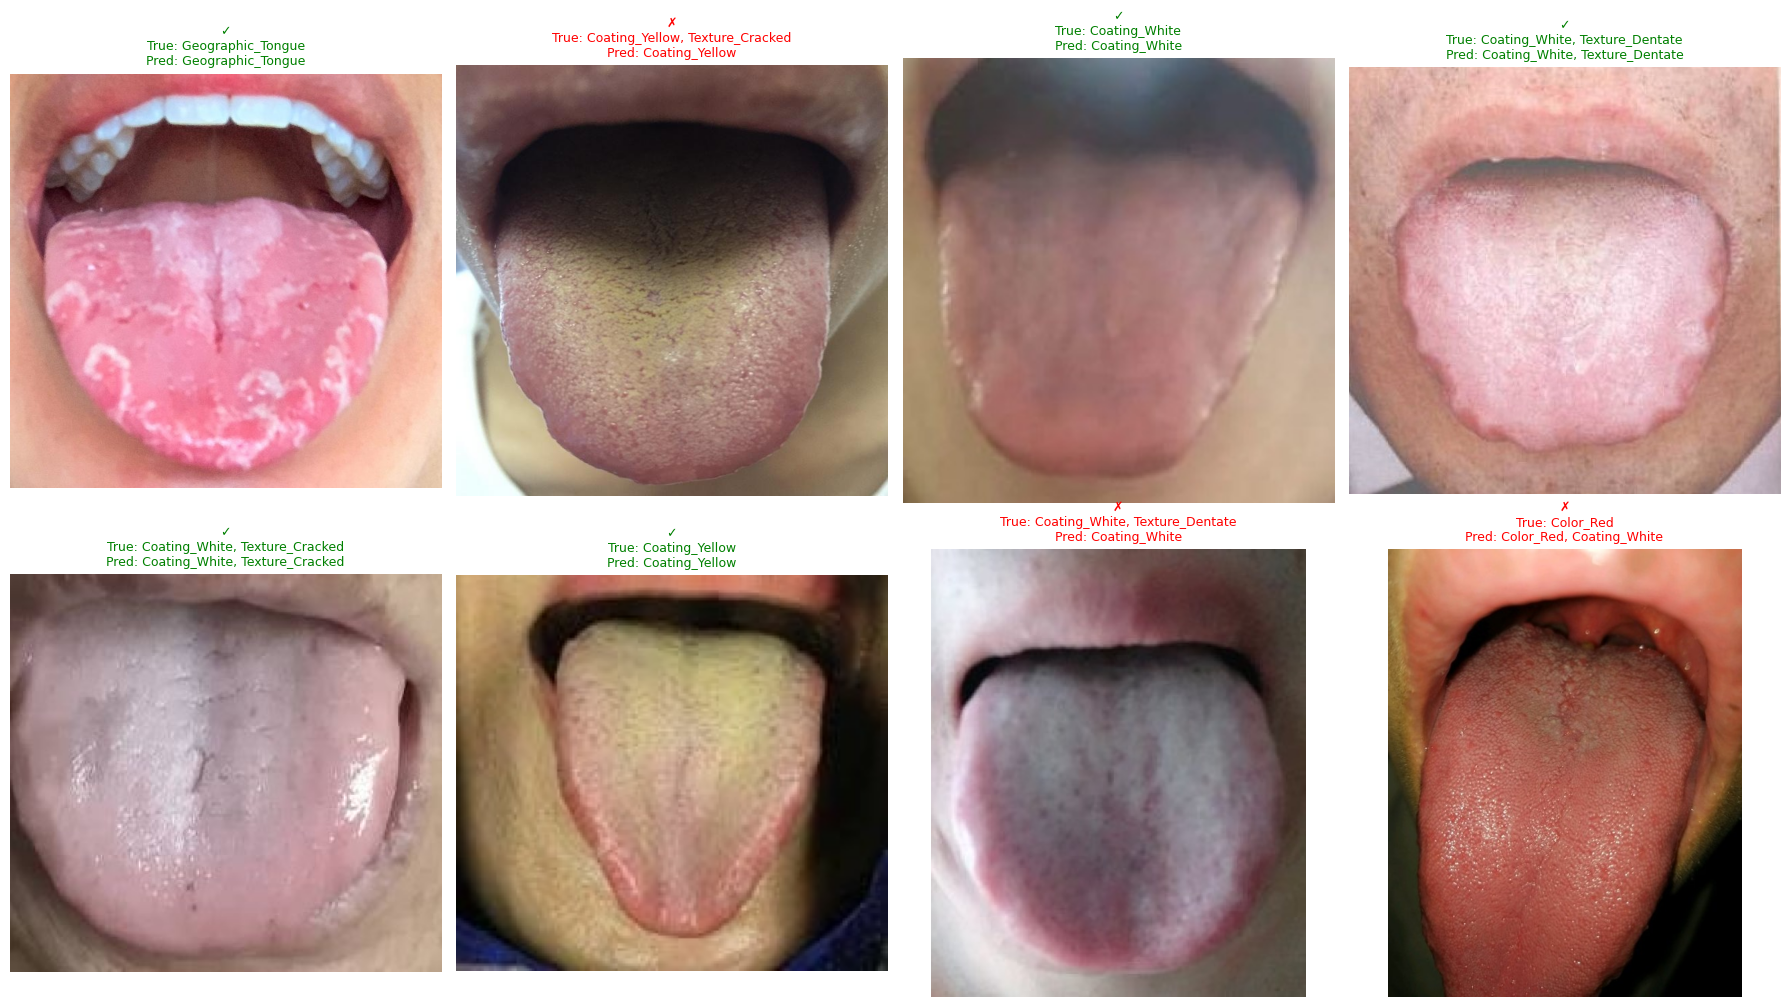

In [ ]:
# Visualize predictions on test images
def visualize_predictions(n_samples=8):
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    indices = np.random.choice(len(test_df), n_samples, replace=False)

    for idx, ax in zip(indices, axes):
        row = test_df.iloc[idx]
        img_path = IMAGE_DIR / row['Image_Name']

        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)

            # Get predictions and ground truth
            true_labels = [LABEL_COLUMNS[i] for i in range(NUM_LABELS) if y_true[idx, i] == 1]
            pred_labels = [LABEL_COLUMNS[i] for i in range(NUM_LABELS) if y_pred[idx, i] == 1]

            # Check if prediction is correct
            is_correct = (y_true[idx] == y_pred[idx]).all()
            color = 'green' if is_correct else 'red'

            title = f"{'✓' if is_correct else '✗'}\n"
            title += f"True: {', '.join(true_labels) if true_labels else 'None'}\n"
            title += f"Pred: {', '.join(pred_labels) if pred_labels else 'None'}"

            ax.set_title(title, fontsize=9, color=color)

        ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_predictions()

## 1️⃣6️⃣ Save Results

In [ ]:
# Save detailed results
results_df = test_df.copy()

# Add predictions
for i, label in enumerate(LABEL_COLUMNS):
    results_df[f'pred_{label}'] = y_pred[:, i]
    results_df[f'prob_{label}'] = probs[:, i]

# Add correctness
results_df['correct'] = (y_true == y_pred).all(axis=1)

results_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

print(f"✓ Detailed results saved to {OUTPUT_DIR / 'test_predictions.csv'}")

✓ Detailed results saved to /content/drive/MyDrive/kaggle_dataset/outputs/test_predictions.csv


## 1️⃣7️⃣ Final Summary

In [ ]:
print("\n" + "="*80)
print("🏥 TONGUE HEALTH CLASSIFICATION - BASELINE MODEL SUMMARY")
print("="*80)

print(f"\n📊 Dataset:")
print(f"  Total samples: {len(df)}")
print(f"  Train: {len(train_df)} (80%)")
print(f"  Val:   {len(val_df)} (10%)")
print(f"  Test:  {len(test_df)} (10%)")
print(f"  Classes: {NUM_LABELS}")

print(f"\n🤖 Model:")
print(f"  Architecture: Vision Transformer + Classifier")
print(f"  Parameters: {trainable_params:,}")
print(f"  Vision Encoder: {MODEL_NAME}")

print(f"\n⚙️ Training:")
print(f"  Epochs trained: {checkpoint['epoch']}")
print(f"  Training time: {total_time/60:.1f} minutes")
print(f"  Best validation F1: {checkpoint['best_val_f1']:.4f}")

print(f"\n📈 Test Performance:")
print(f"  Exact Match Accuracy: {test_metrics['exact_match']:.4f}")
print(f"  F1 Macro:  {test_metrics['f1_macro']:.4f}")
print(f"  F1 Micro:  {test_metrics['f1_micro']:.4f}")
print(f"  Precision: {test_metrics['precision_micro']:.4f}")
print(f"  Recall:    {test_metrics['recall_micro']:.4f}")

print(f"\n📁 Outputs saved to: {OUTPUT_DIR}")
print(f"  - best_model.pt")
print(f"  - training_history.json")
print(f"  - test_metrics.json")
print(f"  - test_predictions.csv")
print(f"  - All visualizations (.png)")

print(f"\n🎯 Top 3 Performing Classes:")
for i, (label, score) in enumerate(sorted_labels[:3], 1):
    print(f"  {i}. {label}: {score:.4f}")

print(f"\n⚠️ Bottom 3 Performing Classes:")
for i, (label, score) in enumerate(sorted_labels[-3:], 1):
    print(f"  {i}. {label}: {score:.4f}")

print("\n" + "="*80)
print("✅ BASELINE COMPLETE!")
print("="*80)


🏥 TONGUE HEALTH CLASSIFICATION - BASELINE MODEL SUMMARY

📊 Dataset:
  Total samples: 3220
  Train: 2576 (80%)
  Val:   322 (10%)
  Test:  322 (10%)
  Classes: 7

🤖 Model:
  Architecture: Vision Transformer + Classifier
  Parameters: 86,917,639
  Vision Encoder: google/vit-base-patch16-224

⚙️ Training:
  Epochs trained: 5
  Training time: 23.2 minutes
  Best validation F1: 0.7550

📈 Test Performance:
  Exact Match Accuracy: 0.6118
  F1 Macro:  0.7917
  F1 Micro:  0.8185
  Precision: 0.8218
  Recall:    0.8153

📁 Outputs saved to: /content/drive/MyDrive/kaggle_dataset/outputs
  - best_model.pt
  - training_history.json
  - test_metrics.json
  - test_predictions.csv
  - All visualizations (.png)

🎯 Top 3 Performing Classes:
  1. Geographic_Tongue: 1.0000
  2. Coating_White: 0.9150
  3. Color_Pink: 0.8000

⚠️ Bottom 3 Performing Classes:
  1. Coating_Yellow: 0.7848
  2. Texture_Dentate: 0.6606
  3. Color_Red: 0.5932

✅ BASELINE COMPLETE!


📷 โหลดไฟล์สำเร็จจากโฟลเดอร์: tongue3.jpg

Symptom (อาการ)      | Confidence (ความมั่นใจ)   | Result (คำวินิจฉัย)
----------------------------------------------------------------------
Color_Pink           |  74.09%                  | 🚨 ตรวจพบอาการนี้
Color_Red            |   0.53%                  | 🟢 ปกติ / ไม่พบ
Coating_White        |  16.00%                  | 🟢 ปกติ / ไม่พบ
Coating_Yellow       |   0.78%                  | 🟢 ปกติ / ไม่พบ
Geographic_Tongue    |   2.32%                  | 🟢 ปกติ / ไม่พบ
Texture_Cracked      |   0.45%                  | 🟢 ปกติ / ไม่พบ
Texture_Dentate      |  23.87%                  | 🟢 ปกติ / ไม่พบ


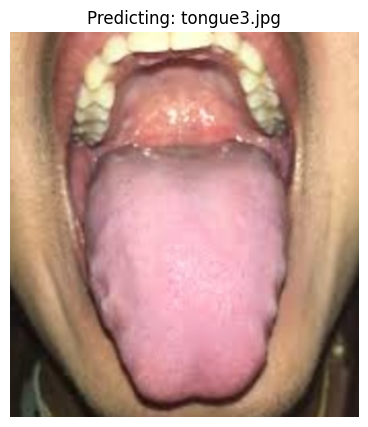

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 1. ระบุชื่อไฟล์รูปภาพของคุณใน Drive ที่ต้องการทดสอบตรงนี้ 📝
# =========================================================
MY_IMAGE_NAME = 'tongue3.jpg'  # ⬅️ เปลี่ยนเป็นชื่อไฟล์รูปภาพของคุณจริง ๆ

# =========================================================
# 2. ระบุ Path ไปยังโฟลเดอร์ที่เก็บรูปภาพโดยตรง 📁
# =========================================================
# เลือกเปิดใช้งานแถวที่ตรงกับโฟลเดอร์ที่คุณเซฟรูปไว้จริง ๆ:

# กรณีที่ 1: ถ้ารูปอยู่ในโฟลเดอร์ images ของโปรเจกต์ (แนะนำ)
CUSTOM_FOLDER_PATH = Path('/content/drive/MyDrive/')

# กรณีที่ 2: ถ้ารูปวางอยู่ข้างนอกโฟลเดอร์หลักของ Drive เลย
# CUSTOM_FOLDER_PATH = Path('/content/drive/MyDrive')


# 3. ตรวจสอบและโหลดรูปภาพจากโฟลเดอร์ที่กำหนด
custom_img_path = CUSTOM_FOLDER_PATH / MY_IMAGE_NAME

if not custom_img_path.exists():
    print(f"❌ หาไฟล์ไม่พบ: ไม่เจอไฟล์ชื่อ '{MY_IMAGE_NAME}'")
    print(f"📍 ตรวจสอบในโฟลเดอร์แล้วไม่เจอ: {CUSTOM_FOLDER_PATH}")
    print("💡 แนะนำให้เช็กตัวสะกดชื่อไฟล์ หรือย้ายรูปภาพไปใส่ไว้ในโฟลเดอร์ด้านบนให้ถูกต้องนะครับ")
else:
    # โหลดรูปภาพและเตรียมข้อมูลส่งเข้าโมเดล
    image = Image.open(custom_img_path).convert('RGB')
    inputs = image_processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(DEVICE)

    # 4. สั่งให้โมเดลทำนายผล (Inference)
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs['logits']
        # แปลงคะแนนดิบเป็นค่าความน่าจะเป็น (Probability 0.0 - 1.0)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    # 5. แสดงผลลัพธ์การวินิจฉัยของโมเดล
    print(f"📷 โหลดไฟล์สำเร็จจากโฟลเดอร์: {MY_IMAGE_NAME}\n")
    print(f"{'Symptom (อาการ)':<20} | {'Confidence (ความมั่นใจ)':<25} | {'Result (คำวินิจฉัย)'}")
    print("-" * 70)

    for i, label in enumerate(LABEL_COLUMNS):
        pred_prob = probs[i]
        percentage = pred_prob * 100

        # ใช้เกณฑ์ 0.5 (หรือ 50%) ในการตัดสินว่าพบอาการหรือไม่
        if pred_prob > 0.5:
            result_status = "🚨 ตรวจพบอาการนี้"
        else:
            result_status = "🟢 ปกติ / ไม่พบ"

        print(f"{label:<20} | {percentage:6.2f}%" + " " * 17 + f" | {result_status}")

    # 6. พลอตแสดงรูปภาพลิ้นที่นำมาเทส
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Predicting: {MY_IMAGE_NAME}")
    plt.axis('off')
    plt.show()